# Notebook 09 — Final Results Dashboard

This notebook consolidates centralized-model performance, federated-learning
performance, and XAI feature-importance results into a final project dashboard.

In [1]:
# ============================================================
# IMPORT LIBRARIES AND LOAD SAVED PROJECT RESULTS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

RESULTS_PATH = PROJECT_ROOT / "results"
FIGURES_PATH = RESULTS_PATH / "figures"

COMPARISON_PATH = (
    RESULTS_PATH
    / "centralized_vs_federated_comparison.csv"
)

TRADEOFF_PATH = (
    RESULTS_PATH
    / "xgboost_vs_federated_tradeoff.csv"
)

SHAP_IMPORTANCE_PATH = (
    RESULTS_PATH
    / "explainability"
    / "shap_global_feature_importance.csv"
)

assert COMPARISON_PATH.exists(), (
    f"Comparison file not found: {COMPARISON_PATH.resolve()}"
)

assert TRADEOFF_PATH.exists(), (
    f"Trade-off file not found: {TRADEOFF_PATH.resolve()}"
)

assert SHAP_IMPORTANCE_PATH.exists(), (
    f"SHAP file not found: {SHAP_IMPORTANCE_PATH.resolve()}"
)

comparison_df = pd.read_csv(COMPARISON_PATH)
tradeoff_df = pd.read_csv(TRADEOFF_PATH)
shap_importance_df = pd.read_csv(SHAP_IMPORTANCE_PATH)

print("✅ All final project results loaded successfully.")

✅ All final project results loaded successfully.


In [2]:
# ============================================================
# DISPLAY ALL CENTRALIZED AND FEDERATED MODEL METRICS
# ============================================================

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy",
]

display_comparison_df = comparison_df.copy()

for metric in metric_columns:
    display_comparison_df[metric] = (
        display_comparison_df[metric] * 100
    ).round(2)

display_comparison_df

,Model,Training Approach,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Logistic Regression,Centralized,95.99,96.80,95.99,96.13,66.69,61.53,66.69
1,Decision Tree,Centralized,99.82,99.84,99.82,99.83,90.65,84.55,90.65
2,Random Forest,Centralized,99.86,99.86,99.86,99.86,84.73,85.65,84.73
3,XGBoost,Centralized,99.87,99.88,99.87,99.87,90.63,89.37,90.63
4,Federated Neural Network (FedAvg),Federated Learning,95.93,98.57,95.93,97.06,93.88,56.84,93.88


In [3]:
# ============================================================
# EXTRACT KEY CENTRALIZED AND FEDERATED RESULTS
# ============================================================

xgboost_result = comparison_df.loc[
    comparison_df["Model"] == "XGBoost"
].iloc[0]

federated_result = comparison_df.loc[
    comparison_df["Training Approach"]
    == "Federated Learning"
].iloc[0]

accuracy_tradeoff = (
    xgboost_result["Accuracy"]
    - federated_result["Accuracy"]
) * 100

macro_f1_tradeoff = (
    xgboost_result["Macro F1"]
    - federated_result["Macro F1"]
) * 100

print("FINAL PROJECT RESULTS")
print("=" * 60)

print(
    f"Best centralized model: XGBoost "
    f"({xgboost_result['Accuracy']:.2%} accuracy)"
)

print(
    f"Federated model: FedAvg Neural Network "
    f"({federated_result['Accuracy']:.2%} accuracy)"
)

print(
    f"Accuracy trade-off: "
    f"{accuracy_tradeoff:.2f} percentage points"
)

print(
    f"Macro F1 trade-off: "
    f"{macro_f1_tradeoff:.2f} percentage points"
)

FINAL PROJECT RESULTS
Best centralized model: XGBoost (99.87% accuracy)
Federated model: FedAvg Neural Network (95.93% accuracy)
Accuracy trade-off: 3.94 percentage points
Macro F1 trade-off: 32.53 percentage points


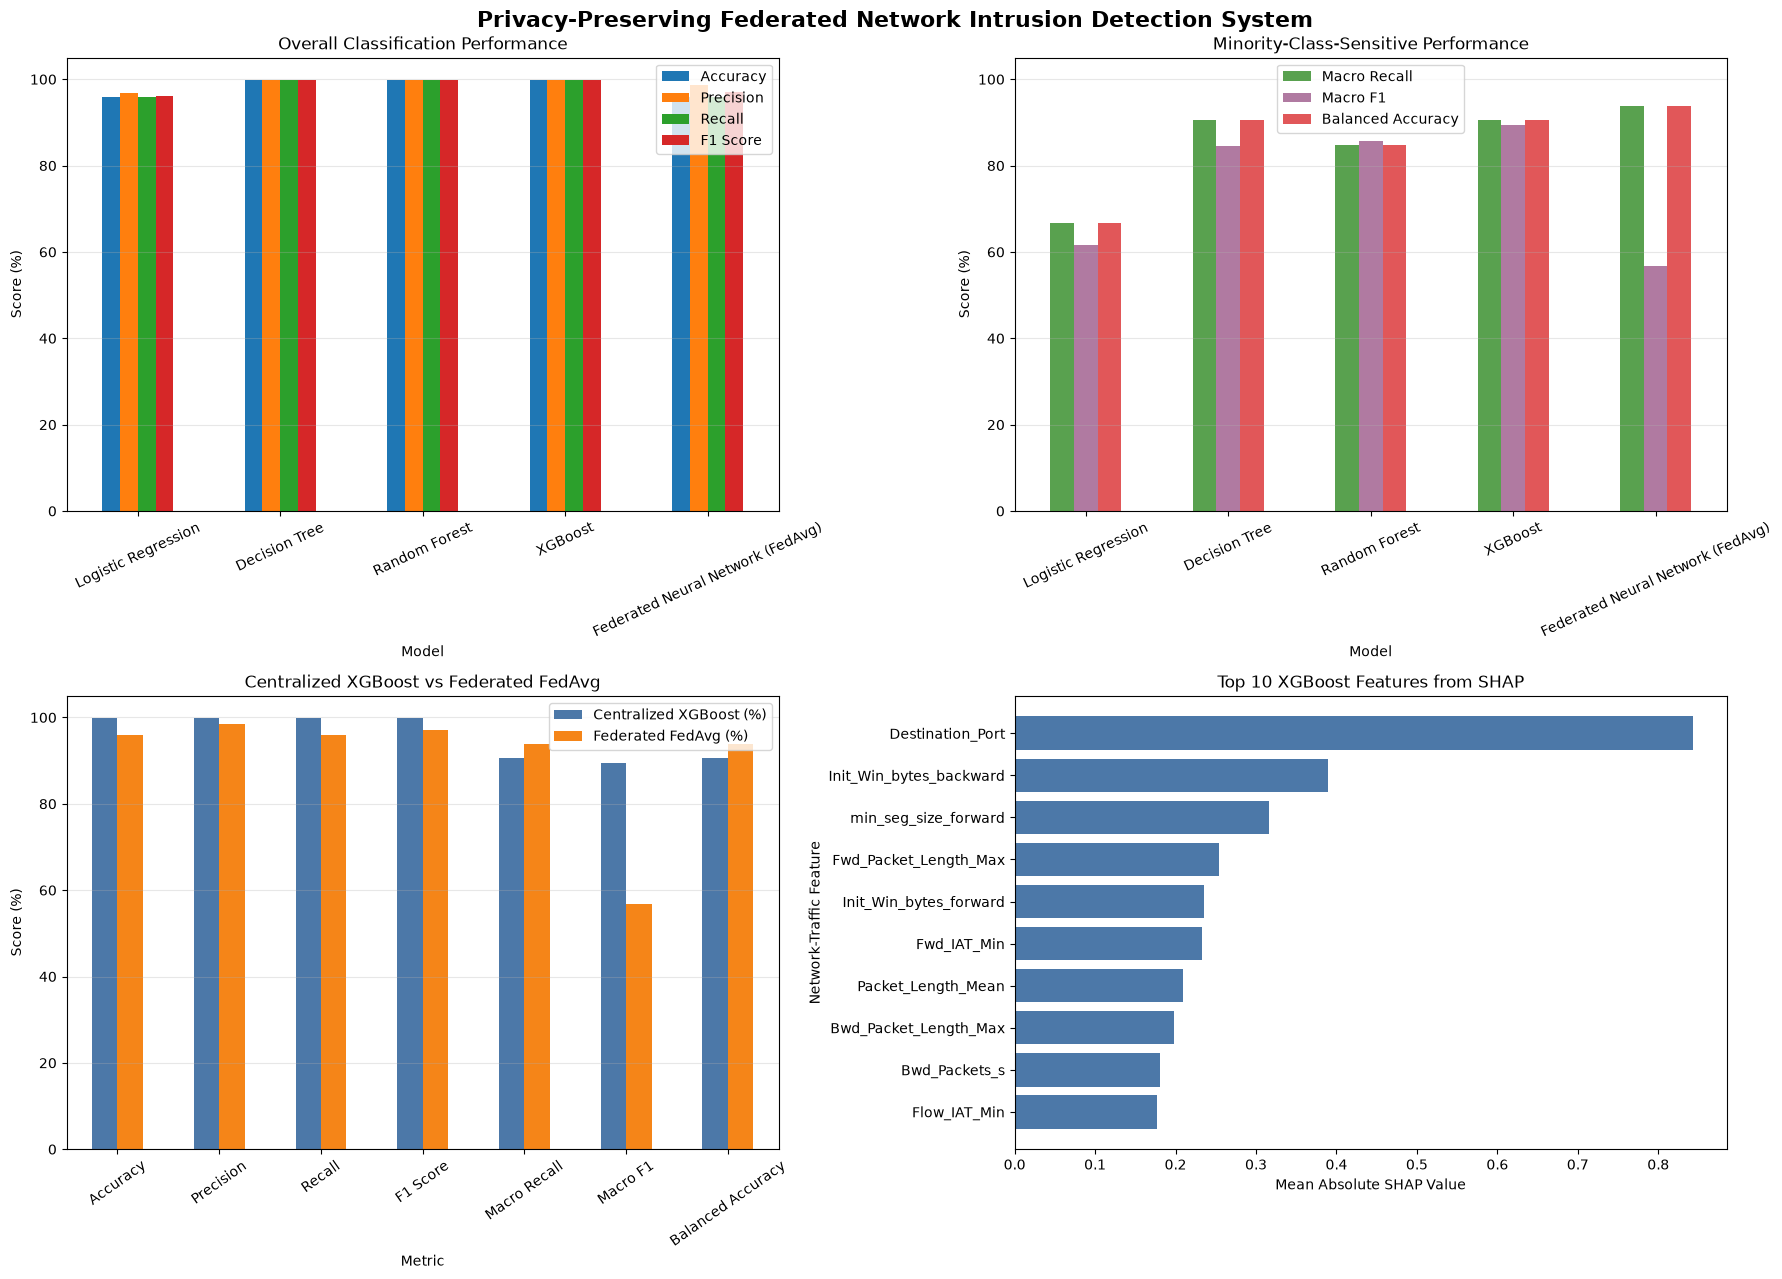

✅ Final dashboard saved to:
C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\figures\final_results_dashboard.png


In [4]:
# ============================================================
# CREATE A FOUR-PANEL PROJECT RESULTS DASHBOARD
# ============================================================

overall_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
]

balanced_metrics = [
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy",
]

plot_data = comparison_df.set_index("Model")

top_shap_features = (
    shap_importance_df
    .head(10)
    .sort_values(
        by="Mean Absolute SHAP Value",
        ascending=True,
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13),
)

# ------------------------------------------------------------
# Panel 1: Overall classification metrics
# ------------------------------------------------------------

(
    plot_data[overall_metrics]
    .multiply(100)
    .plot(
        kind="bar",
        ax=axes[0, 0],
    )
)

axes[0, 0].set_title(
    "Overall Classification Performance"
)

axes[0, 0].set_xlabel("Model")
axes[0, 0].set_ylabel("Score (%)")
axes[0, 0].set_ylim(0, 105)
axes[0, 0].tick_params(
    axis="x",
    rotation=25,
)
axes[0, 0].grid(
    axis="y",
    alpha=0.3,
)

# ------------------------------------------------------------
# Panel 2: Macro and balanced metrics
# ------------------------------------------------------------

(
    plot_data[balanced_metrics]
    .multiply(100)
    .plot(
        kind="bar",
        ax=axes[0, 1],
        color=["#59A14F", "#B07AA1", "#E15759"],
    )
)

axes[0, 1].set_title(
    "Minority-Class-Sensitive Performance"
)

axes[0, 1].set_xlabel("Model")
axes[0, 1].set_ylabel("Score (%)")
axes[0, 1].set_ylim(0, 105)
axes[0, 1].tick_params(
    axis="x",
    rotation=25,
)
axes[0, 1].grid(
    axis="y",
    alpha=0.3,
)

# ------------------------------------------------------------
# Panel 3: XGBoost vs FedAvg trade-off
# ------------------------------------------------------------

tradeoff_plot_df = tradeoff_df.set_index("Metric")

tradeoff_plot_df[
    [
        "Centralized XGBoost (%)",
        "Federated FedAvg (%)",
    ]
].plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#4C78A8", "#F58518"],
)

axes[1, 0].set_title(
    "Centralized XGBoost vs Federated FedAvg"
)

axes[1, 0].set_xlabel("Metric")
axes[1, 0].set_ylabel("Score (%)")
axes[1, 0].set_ylim(0, 105)
axes[1, 0].tick_params(
    axis="x",
    rotation=35,
)
axes[1, 0].grid(
    axis="y",
    alpha=0.3,
)

# ------------------------------------------------------------
# Panel 4: SHAP feature importance
# ------------------------------------------------------------

axes[1, 1].barh(
    top_shap_features["Feature"],
    top_shap_features["Mean Absolute SHAP Value"],
    color="#4C78A8",
)

axes[1, 1].set_title(
    "Top 10 XGBoost Features from SHAP"
)

axes[1, 1].set_xlabel(
    "Mean Absolute SHAP Value"
)

axes[1, 1].set_ylabel(
    "Network-Traffic Feature"
)

fig.suptitle(
    "Privacy-Preserving Federated Network Intrusion Detection System",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

DASHBOARD_FIGURE_PATH = (
    FIGURES_PATH / "final_results_dashboard.png"
)

plt.savefig(
    DASHBOARD_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Final dashboard saved to:")
print(DASHBOARD_FIGURE_PATH.resolve())

In [5]:
# ============================================================
# DISPLAY THE TEN MOST INFLUENTIAL XGBOOST FEATURES
# ============================================================

top_shap_features_display = (
    shap_importance_df
    .head(10)
    .copy()
)

top_shap_features_display.index = (
    top_shap_features_display.index + 1
)

top_shap_features_display

,Feature,Mean Absolute SHAP Value
1,Destination_Port,0.843001
2,Init_Win_bytes_backward,0.389938
3,min_seg_size_forward,0.315803
4,Fwd_Packet_Length_Max,0.253695
5,Init_Win_bytes_forward,0.235685
6,Fwd_IAT_Min,0.233323
7,Packet_Length_Mean,0.209181
8,Bwd_Packet_Length_Max,0.198664
9,Bwd_Packets_s,0.181113
10,Flow_IAT_Min,0.176545


In [6]:
# ============================================================
# SAVE A COMPACT PROJECT SUMMARY FOR REPORTING
# ============================================================

project_summary_df = pd.DataFrame(
    {
        "Item": [
            "Best Centralized Model",
            "Centralized XGBoost Accuracy",
            "Federated FedAvg Accuracy",
            "Accuracy Trade-off",
            "Centralized XGBoost Macro F1",
            "Federated FedAvg Macro F1",
            "Macro F1 Trade-off",
        ],
        "Value": [
            "XGBoost",
            f"{xgboost_result['Accuracy']:.2%}",
            f"{federated_result['Accuracy']:.2%}",
            f"{accuracy_tradeoff:.2f} percentage points",
            f"{xgboost_result['Macro F1']:.2%}",
            f"{federated_result['Macro F1']:.2%}",
            f"{macro_f1_tradeoff:.2f} percentage points",
        ],
    }
)

PROJECT_SUMMARY_PATH = (
    RESULTS_PATH / "final_project_summary.csv"
)

project_summary_df.to_csv(
    PROJECT_SUMMARY_PATH,
    index=False,
)

print("✅ Final summary saved to:")
print(PROJECT_SUMMARY_PATH.resolve())

project_summary_df

✅ Final summary saved to:
C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\final_project_summary.csv


,Item,Value
0,Best Centralized Model,XGBoost
1,Centralized XGBoost Accuracy,99.87%
2,Federated FedAvg Accuracy,95.93%
3,Accuracy Trade-off,3.94 percentage points
4,Centralized XGBoost Macro F1,89.37%
5,Federated FedAvg Macro F1,56.84%
6,Macro F1 Trade-off,32.53 percentage points


In [7]:
# ============================================================
# PRINT FINAL PROJECT CONCLUSION
# ============================================================

print("PROJECT CONCLUSION")
print("=" * 60)

print(
    "The centralized XGBoost model achieved the strongest "
    "intrusion-detection performance."
)

print(
    "The Federated Neural Network achieved competitive results "
    "while using FedAvg to aggregate model updates rather than "
    "sharing raw client network-traffic records."
)

print(
    "SHAP analysis identifies the network-traffic features that "
    "most influenced the final XGBoost predictions."
)

print(
    "The project therefore demonstrates the accuracy-versus-privacy "
    "trade-off in federated network intrusion detection."
)

PROJECT CONCLUSION
The centralized XGBoost model achieved the strongest intrusion-detection performance.
The Federated Neural Network achieved competitive results while using FedAvg to aggregate model updates rather than sharing raw client network-traffic records.
SHAP analysis identifies the network-traffic features that most influenced the final XGBoost predictions.
The project therefore demonstrates the accuracy-versus-privacy trade-off in federated network intrusion detection.
